In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# Three phases at once, from one equation of state (CO₂ / *n*-decane)

This notebook works **Illustration 11.3-2**: the pressure and vapor composition in
equilibrium with the *two* coexisting liquid phases of carbon dioxide + *n*-decane,
from the Peng-Robinson equation of state with $k_{12} = 0.114$.

**What is different about this one.** Everywhere else in Section 11.3 the two liquids
are described by activity coefficients, so the liquid-liquid problem can be solved
first and a bubble point taken afterwards — the liquid compositions do not depend on
pressure. An equation of state has no such shortcut. The same cubic describes all
three phases; the only thing that distinguishes a liquid from a vapor is **which root
of it you take**, which is the one sentence Section 11.2 spends on the whole method.
So all four unknowns — both liquid compositions, the vapor composition, and the
pressure — come out of one simultaneous solve.

**This is the calculation the book could not previously ask you to do.** Its solution sends the
reader to "the Visual Basic program of Appendix B.I-3, the DOS-based program VLMU, or
the MATHCAD worksheet PRBUBP" — three obsolete artifacts in one sentence, the most
legacy-bound line in the book. It is `lle.eos_vlle_binary` now, and the algorithm is
about forty lines.

Section 11.3 notes that its three-phase examples "were done as two separate
two-phase calculations" and leaves the simultaneous algorithm as **Problem 11.3-7**.
Both are below, and comparing them is the most interesting thing here.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.peng_robinson import PengRobinson
from thermo.pr_mixture import PRMixture
from thermo.charts import use_book_style
from thermo import lle

use_book_style()
BAR = 1e5
K12 = 0.114                              # SIS Table 9.4-1, CO2 / n-decane

# SIS Table 6.6-1's constants, which is what the illustrations are computed with
co2    = PengRobinson(Tc=304.2, Pc=7.376e6, omega=0.225, name="carbon dioxide")
decane = PengRobinson(Tc=617.6, Pc=2.108e6, omega=0.490, name="n-decane")
mix = PRMixture([co2, decane], kij=[[0.0, K12], [K12, 0.0]])

for c in mix.components:
    print(f"  {c.name:16s} Tc = {c.Tc:6.1f} K   Pc = {c.Pc / BAR:6.2f} bar   "
          f"omega = {c.omega:.3f}")

  carbon dioxide   Tc =  304.2 K   Pc =  73.76 bar   omega = 0.225
  n-decane         Tc =  617.6 K   Pc =  21.08 bar   omega = 0.490



## The equilibrium conditions

Three phases, two species, equal fugacity of each species in each phase:

$$x_i^{\rm I}\phi_i(x^{\rm I}, T, P) \;=\; x_i^{\rm II}\phi_i(x^{\rm II}, T, P)
  \;=\; y_i\,\phi_i(y, T, P) \qquad i = 1, 2$$

Four independent equations. The unknowns are $x_1^{\rm I}$, $x_1^{\rm II}$, $y_1$ and
$P$ — also four, which is the Gibbs phase rule saying the same thing: with $\mathcal{C}
= 2$ and $\mathcal{P} = 3$ there is one degree of freedom, and specifying $T$ has used
it. At each temperature there is exactly **one** three-phase pressure and all three
compositions are fixed; changing the overall feed moves mass between the phases and
nothing else.

Every $\phi_i$ above comes from the same equation of state. The first two are evaluated
at the **liquid** root of the cubic and the third at the **vapor** root.


In [3]:
printed = [(235.65, 10.84, 0.539, 0.997, 1.2e-6), (236.15, 11.01, 0.540, 0.996, 1.3e-6),
           (238.15, 11.82, 0.552, 0.996, 1.6e-6), (240.15, 12.66, 0.563, 0.995, 2.0e-6),
           (242.15, 13.56, 0.575, 0.995, 2.4e-6), (244.15, 14.49, 0.586, 0.994, 3.0e-6),
           (246.15, 15.46, 0.597, 0.993, 3.6e-6), (248.74, 16.76, 0.609, 0.992, 4.7e-6)]

print(f"  {'T (K)':>7s}   {'P (bar)':>15s}   {'x_CO2 (I)':>15s}   "
      f"{'x_CO2 (II)':>15s}   {'y_decane':>19s}")
print(f"  {'':>7s}   {'SIS  computed':>15s}   {'SIS  computed':>15s}   "
      f"{'SIS  computed':>15s}   {'SIS   computed':>19s}")
for T, Pb, xIb, xIIb, yb in printed:
    P, y, xI, xII = lle.eos_vlle_binary(mix, T)
    print(f"  {T:7.2f}   {Pb:6.2f}{P / BAR:9.3f}   {xIb:6.3f}{xI[0]:9.4f}   "
          f"{xIIb:6.3f}{xII[0]:9.4f}   {yb:8.1e}{y[1]:11.3e}")

    T (K)           P (bar)         x_CO2 (I)        x_CO2 (II)              y_decane
              SIS  computed     SIS  computed     SIS  computed        SIS   computed
   235.65    10.84   10.825    0.539   0.5375    0.997   0.9965    1.2e-06  1.237e-06
   236.15    11.01   11.020    0.540   0.5403    0.996   0.9964    1.3e-06  1.303e-06
   238.15    11.82   11.824    0.552   0.5516    0.996   0.9959    1.6e-06  1.600e-06
   240.15    12.66   12.670    0.563   0.5630    0.995   0.9953    2.0e-06  1.964e-06
   242.15    13.56   13.560    0.575   0.5743    0.995   0.9946    2.4e-06  2.408e-06
   244.15    14.49   14.494    0.586   0.5857    0.994   0.9938    3.0e-06  2.951e-06
   246.15    15.46   15.474    0.597   0.5971    0.993   0.9929    3.6e-06  3.614e-06


   248.74    16.76   16.813    0.609   0.6118    0.992   0.9916    4.7e-06  4.697e-06


Every pressure within 0.06 bar, every liquid composition within 0.003, and the vapor
composition — a number that ranges over a factor of four and is of order $10^{-6}$ —
right to both printed figures at all eight temperatures.

## Where the constants come from, and the 2 % they move the pressure

The cell above did **not** build the mixture from the package's property database. It
used Table 6.6-1's constants directly, because for carbon dioxide the two sources
disagree: the book prints $\omega = 0.225$ and the database — which is Reid, Prausnitz
and Poling, 4th ed., and says so — carries **0.239**. For *n*-decane they agree to the
third figure.

That difference is invisible in most calculations and not in this one. At these
temperatures the three-phase pressure is set almost entirely by carbon dioxide (the
CO₂-rich liquid is 99.7 % CO₂), so an error in CO₂'s vapor pressure passes straight
through to $P$.


In [4]:
db_mix = PRMixture.from_database(["carbon dioxide", "n-decane"],
                                 kij=[[0.0, K12], [K12, 0.0]])

print(f"  {'T (K)':>7s} {'P SIS':>7s} {'Table 6.6-1':>12s} {'RPP database':>13s}"
      f"   {'CO2 Psat: 6.6-1':>16s} {'RPP':>8s}")
for T, Pb, *_ in printed[::3]:
    P1 = lle.eos_vlle_binary(mix, T)[0]
    P2 = lle.eos_vlle_binary(db_mix, T)[0]
    ps1 = co2.vapor_pressure(T) / BAR
    ps2 = db_mix.components[0].vapor_pressure(T) / BAR
    print(f"  {T:7.2f} {Pb:7.2f} {P1 / BAR:12.3f} {P2 / BAR:13.3f}   "
          f"{ps1:16.3f} {ps2:8.3f}")

print("\n  the whole discrepancy is CO2's vapor pressure, and omega is the only")
print("  constant the two sources disagree about")

    T (K)   P SIS  Table 6.6-1  RPP database    CO2 Psat: 6.6-1      RPP
   235.65   10.84       10.825        10.639             10.865   10.677
   240.15   12.66       12.670        12.475             12.732   12.535
   246.15   15.46       15.474        15.270             15.586   15.379

  the whole discrepancy is CO2's vapor pressure, and omega is the only
  constant the two sources disagree about



**Neither number is wrong.** They are two property compilations, and the book's
illustrations were computed with the book's own table — which is the reason to use it
here. The same question decided the ideal-gas heat capacities in Chapter 6, where the
package carries the book's Appendix A.II coefficients alongside the database ones for
exactly this reason.

**Carry this forward:** an acentric factor quoted to three decimals looks like a
constant of nature. It is a fitted number, it differs between compilations, and here a
6 % difference in $\omega$ is worth 2 % in a pressure.

## Two two-phase calculations, or one four-unknown solve?

Section 11.3 says its three-phase examples "were done as two separate two-phase
calculations" — solve the liquid-liquid problem, then take a bubble point on one of the
liquids — and immediately warns that this "cannot easily be followed in a three-phase
flash calculation," leaving the simultaneous algorithm as **Problem 11.3-7**.

The two-step route has a chicken-and-egg problem the text does not dwell on: the
liquid-liquid calculation needs a pressure *before* the bubble point has produced one.
Illustration 11.2-5 used the measured pressure; here the seed is the vapor pressure of
pure CO₂, which needs nothing measured.


In [5]:
print(f"  {'T (K)':>7s} {'two-step P':>11s} {'simultaneous P':>15s} {'SIS':>7s}"
      f"   {'x_I two-step':>13s} {'simultaneous':>13s}")
for T, Pb, *_ in printed:
    P_seed = co2.vapor_pressure(T)                 # a pressure to start the LLE from
    xI0, xII0 = lle.eos_binary_lle(mix, T, P_seed)
    P_2step, y_2step = mix.bubble_pressure(xI0, T, P_guess=P_seed)
    P, y, xI, xII = lle.eos_vlle_binary(mix, T)
    print(f"  {T:7.2f} {P_2step / BAR:11.3f} {P / BAR:15.3f} {Pb:7.2f}"
          f"   {xI0[0]:13.4f} {xI[0]:13.4f}")

    T (K)  two-step P  simultaneous P     SIS    x_I two-step  simultaneous


   235.65      10.825          10.825   10.84          0.5375        0.5375
   236.15      11.020          11.020   11.01          0.5403        0.5403
   238.15      11.824          11.824   11.82          0.5516        0.5516
   240.15      12.670          12.670   12.66          0.5630        0.5630


   242.15      13.560          13.560   13.56          0.5743        0.5743


   244.15      14.494          14.494   14.49          0.5857        0.5857
   246.15      15.474          15.474   15.46          0.5971        0.5971
   248.74      16.812          16.813   16.76          0.6118        0.6118



**Identical to the last digit — and that is a fact about this system, not about the
method.** CO₂ + *n*-decane is forgiving: its three-phase pressure is within a quarter of
a bar of pure CO₂'s vapor pressure, and its liquid compositions barely move over that
range, so the liquid-liquid step was solved at essentially the right pressure by luck.
Sweep the seed and you can watch how little it matters here.

## Where the two-step route does break

Ask for the liquid-liquid equilibrium at a pressure **above** the three-phase
pressure — which is legitimate, the two liquids exist there — and then take a bubble
point on one of them. The bubble-point routine returns an answer, it converges, and the
answer is wrong in an interesting way.


In [6]:
T = 235.65
P3 = lle.eos_vlle_binary(mix, T)[0]
print(f"  the three-phase pressure at {T} K is {P3 / BAR:.3f} bar\n")

print(f"  {'LLE solved at':>14s} {'x_I':>8s} {'x_II':>8s}   {'bubble P':>9s} "
      f"{'incipient y_CO2':>16s}")
for Pg in (8, 10, 15, 20, 30, 50):
    xI0, xII0 = lle.eos_binary_lle(mix, T, Pg * BAR)
    P_2step, y_2step = mix.bubble_pressure(xI0, T, P_guess=Pg * BAR)
    print(f"  {Pg:11d} bar {xI0[0]:8.4f} {xII0[0]:8.4f}   {P_2step / BAR:9.3f} "
          f"{y_2step[0]:16.6f}")

  the three-phase pressure at 235.65 K is 10.825 bar

   LLE solved at      x_I     x_II    bubble P  incipient y_CO2


            8 bar   0.5380   0.9965      10.832         0.999999


           10 bar   0.5376   0.9965      10.827         0.999999
           15 bar   0.5368   0.9966      10.816         0.999999
           20 bar   0.5359   0.9966      10.805         0.999999
           30 bar   0.5342   0.9967      30.000         0.996707
           50 bar   0.5308   0.9969      50.000         0.996886



**Look at the last two rows.** The "bubble pressure" comes back equal to the pressure
the calculation was started at, and the "vapor" it reports has the composition of the
CO₂-rich **liquid** — 0.9967, which is $x^{\rm II}$ in the same row.

The reason is the sentence this whole notebook rests on, turned against us. A vapor and
a liquid are the same cubic and differ only in which root you take, so `phi(y, T, P,
phase="vapor")` means "the largest root." Above the three-phase pressure the cubic at
that composition has only **one** root, and the largest root is then the liquid one.
The vapor equation $x_i^{\rm I}\phi_i = y_i\phi_i$ is therefore satisfied *exactly* by
$y = x^{\rm II}$ — a genuine root of the equations that describes three liquids and no
vapor.

**A converged solve is not a physical answer**, and no residual test catches this
one: the residual really is zero. `eos_vlle_binary` checks the *compositions* instead
and refuses when the vapor is indistinguishable from either liquid.


In [7]:
import warnings

for P_guess in (10.9, 30.0):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        got = lle.eos_vlle_binary(mix, T, P_guess=P_guess * BAR)
    if got is None:
        print(f"  seeded at {P_guess:5.1f} bar -> None, and it says why:")
        # split on ';' rather than '.' -- the message carries decimal numbers
        print(f"     {str(caught[0].message).split(';')[0]}.")
    else:
        print(f"  seeded at {P_guess:5.1f} bar -> P = {got[0] / BAR:.3f} bar, "
              f"y_CO2 = {got[1][0]:.6f}")

  seeded at  10.9 bar -> P = 10.825 bar, y_CO2 = 0.999999
  seeded at  30.0 bar -> None, and it says why:
     eos_vlle_binary converged at T = 235.65 K to P = 3e+06 Pa with a vapor indistinguishable from liquid II.



## Why there is almost no decane in the vapor

The vapor is $10^{-6}$ decane, and the illustration attributes that to "the large
volatility difference." That is checkable in one line: at these temperatures decane's
vapor pressure is smaller than CO₂'s by six orders of magnitude.


In [8]:
for T in (235.65, 248.74):
    p_co2 = co2.vapor_pressure(T) / BAR
    p_c10 = decane.vapor_pressure(T) / BAR
    P, y, xI, xII = lle.eos_vlle_binary(mix, T)
    print(f"  T = {T:.2f} K:  Psat CO2 = {p_co2:8.3f} bar,  Psat decane = "
          f"{p_c10:.2e} bar,  ratio {p_co2 / p_c10:.1e}")
    print(f"     ideal (Raoult) estimate of y_decane from liquid I: "
          f"{xI[1] * p_c10 / (P / BAR):.2e}   actual {y[1]:.2e}")

  T = 235.65 K:  Psat CO2 =   10.865 bar,  Psat decane = 8.13e-06 bar,  ratio 1.3e+06


     ideal (Raoult) estimate of y_decane from liquid I: 3.48e-07   actual 1.24e-06
  T = 248.74 K:  Psat CO2 =   16.955 bar,  Psat decane = 3.39e-05 bar,  ratio 5.0e+05
     ideal (Raoult) estimate of y_decane from liquid I: 7.83e-07   actual 4.70e-06



The Raoult's-law estimate is the right order of magnitude and not the right number —
which is why it is done with an equation of state. At 10 bar the vapor is not
ideal and the liquid is nowhere near it.

## The three-phase line, drawn

The eight rows are a curve. Plotting the three coexisting compositions against
temperature gives the shape Section 11.3 describes in words: two liquid branches
converging as the liquid-liquid critical point is approached, and a vapor branch pinned
against pure CO₂.


  the two liquid branches are still 0.378 apart at 249.0 K
  measured, they merge at 248.74 K and x = 0.850 (Illustration 11.2-5)


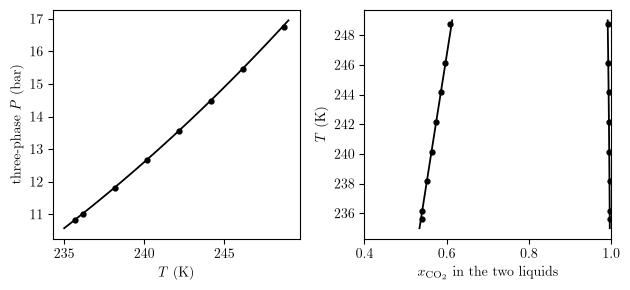

In [9]:
Ts = np.linspace(235.0, 249.0, 57)
rows = [(T, lle.eos_vlle_binary(mix, T)) for T in Ts]
rows = [(T, r) for T, r in rows if r is not None]
Tg = np.array([T for T, _ in rows])
P = np.array([r[0] for _, r in rows]) / BAR
xI = np.array([r[2][0] for _, r in rows])
xII = np.array([r[3][0] for _, r in rows])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.4, 3.0))
ax1.plot(Tg, P, "k-", lw=1.3)
ax1.plot([r[0] for r in printed], [r[1] for r in printed], "ko", ms=3.5)
ax1.set_xlabel(r"$T$ (K)"); ax1.set_ylabel(r"three-phase $P$ (bar)")

ax2.plot(xI, Tg, "k-", lw=1.3)
ax2.plot(xII, Tg, "k-", lw=1.3)
for col in (2, 3):                                   # both printed liquid branches
    ax2.plot([r[col] for r in printed], [r[0] for r in printed], "ko", ms=3.5)
ax2.set_xlabel(r"$x_{\rm CO_2}$ in the two liquids"); ax2.set_ylabel(r"$T$ (K)")
ax2.set_xlim(0.4, 1.0)
fig.tight_layout()

print(f"  the two liquid branches are still {xII[-1] - xI[-1]:.3f} apart at "
      f"{Tg[-1]:.1f} K")
print(f"  measured, they merge at 248.74 K and x = 0.850 (Illustration 11.2-5)")


**The predicted branches do not close where the measured ones do**, and Illustration
11.2-5 says so directly: $k_{12} = 0.114$, fitted to higher-temperature vapor-liquid
data, "results in a much higher liquid-liquid critical solution temperature than is
observed in the laboratory," and no choice of $k_{12}$ fixes the shape.

**That is the honest reading of this illustration:
the numbers reproduced above are a faithful reproduction of a mediocre prediction.**
Section 11.2's own comment is the right one — what is remarkable is not the poor
liquid-liquid accuracy but that one simple cubic gives good vapor-liquid predictions
over a wide range *and* a qualitatively right liquid-liquid picture at low temperature.
The Wong-Sandler mixing rule of Section 9.9 fixes the shape; its parameters are not
printed, so reproducing that curve means fitting them, which is Illustration 11.2-5's
own job rather than this one's.

## Your turn

1. Compare the computed liquid compositions with the **measured** ones in Illustration
   11.2-5's table (0.577 / 0.974 at 235.65 K, closing at 0.850 / 0.850 at 248.74 K).
   How far off is the predicted critical solution temperature?
2. Try to fix it with $k_{12}$: sweep it and plot the predicted coexistence curve
   against the data. Section 11.2 says no value works — confirm that, and say what
   specifically fails.
3. **Problem 11.3-7** asks for the three-phase *flash* algorithm — given an overall
   feed at fixed $T$ and $P$, find how much of it is in each phase. Add the two mass
   balances to the four equilibrium equations here and solve for the phase fractions.
4. Repeat the whole calculation with the database's $\omega_{\rm CO_2} = 0.239$ and
   decide for yourself which set you would publish with, and what you would say about
   it in the caption.
5. The vapor is 99.9999 % CO₂. What does that make this system, from a separations
   point of view — and how does it compare with the steam distillation of Section
   11.3's last illustration, where the same near-immiscibility is what the separation exploits?
6. At 248.74 K the measured liquids merge. Above that temperature `eos_vlle_binary`
   still returns an answer for a while. Find the temperature at which it stops, and
   explain what that temperature is for the *model* as opposed to the fluid.
